# ECMWF Tropical Cyclone Processing Pipeline

This notebook demonstrates how to use the ECMWF tropical cyclone processing pipeline modules.

## Pipeline Overview

The pipeline consists of 6 main steps:
1. **Download TC Data** - Download tropical cyclone track BUFR files
2. **Extract BUFR Data** - Extract structured data from BUFR files  
3. **Transform Data** - Convert to standardized format with wind radii
4. **Download Wind Data** - Download ensemble wind forecasts
5. **Process Wind Combination** - Create wind threshold envelopes

## Output Files

1. **TC Track Data** (`*_transformed.csv`) - Individual forecast points with wind radii
2. **Individual Wind Envelopes** (`*_envelopes_individual.csv`) - Wind threshold polygons per forecast step
3. **Combined Wind Envelopes** (`*_envelopes_combined.csv`) - Combined wind threshold polygons


## Setup


In [1]:
import os
import pandas as pd
from pathlib import Path
from datetime import datetime, timedelta

from numpy.f2py.crackfortran import verbose

# Import pipeline modules
from ecmwf_tc_data_downloader import download_tc_data, get_available_dates
from ecmwf_tc_data_extractor import extract_tc_data_from_file
from ecmwf_tc_data_transformer import transform_tc_data_from_file
from ecmwf_wind_data_downloader import download_ensemble_wind
from ecmwf_tc_wind_combination import process_wind_combination

In [2]:
# Get available dates and show options
available_dates = get_available_dates()

print("Available dates:")
for i, date in enumerate(available_dates[:4]):  # First 4 dates (most recent)
    # Parse the date: YYYYMMDDHHMMSS -> YYYY-MM-DD HHZ
    date_str = date[:8]  # YYYYMMDD
    run_time = date[8:10]  # HH
    human_date = f"{date_str[:4]}-{date_str[4:6]}-{date_str[6:8]}"

    if i == 0:  # Most recent date
        print(f"  Today: {human_date} {run_time}Z (May not be fully published)")
    else:
        print(f"  {human_date} {run_time}Z")

print("\nAvailable run times: 00, 06, 12, 18 (UTC)")

# User configuration - modify these values
SELECTED_DATE = available_dates[1][:8]  # Second most recent date (YYYYMMDD format)
SELECTED_RUNTIME = available_dates[1][8:10]  # Run time from that date

print(f"\nSelected: {SELECTED_DATE} {SELECTED_RUNTIME}Z")


Found 121 forecast dates
Available dates:
  Today: 2025-11-02 00Z (May not be fully published)
  2025-11-01 18Z
  2025-11-01 12Z
  2025-11-01 06Z

Available run times: 00, 06, 12, 18 (UTC)

Selected: 20251101 18Z


In [3]:
SELECTED_DATE = '20251102'
SELECTED_RUNTIME = '00'  # Run time from that date

In [4]:
# Create output directories
directories = {
    'tc_data': 'tc_data',
    'tc_extracted': 'tc_extracted', 
    'tc_transformed': 'tc_transformed',
    'wind_data': 'wind_data',
    'wind_extracted': 'wind_extracted'
}

for dir_path in directories.values():
    Path(dir_path).mkdir(exist_ok=True)

## Step 1: Download TC Data


In [5]:
# Download TC data for selected date
tc_files = download_tc_data(
    date=SELECTED_DATE,
    run_time=SELECTED_RUNTIME,
    output_dir=directories['tc_data'],
    named_storms_only=True
)


Found 121 forecast dates
Filtering for run time: 00Z
Processing 1 forecast(s)

   Found 1 tropical cyclone track files
   Downloaded: A_JSXX01ECEP020000_C_ECMP_20251102000000_tropical_cyclone_track_KALMAEGI_134p4degE_11degN_bufr4.bin (54,084 bytes)

Summary:
   Successfully downloaded: 1 files
   Failed downloads: 0 files
   Files saved to: tc_data/


## Step 2: Extract BUFR Data


In [6]:
# Extract data from BUFR files
bufr_files = list(Path(directories['tc_data']).glob("*.bin"))
extraction_results = []

for bufr_file in bufr_files:
    result = extract_tc_data_from_file(
        filename=str(bufr_file),
        output_dir=directories['tc_extracted'],
        verbose=True
    )
    if result['success']:
        extraction_results.append(result)


Extracting tropical cyclone data from: tc_data/A_JSXX01ECEP020000_C_ECMP_20251102000000_tropical_cyclone_track_KALMAEGI_134p4degE_11degN_bufr4.bin
**************** MESSAGE:  1   *****************
Date and time:  2 . 11 . 2025    0 : 0
Storm identifier:  31W
Number of Ensemble Members:  52
== Member  1
step  latitude  longitude   pressure  latitude   longitude    wind
   0    11.0      135.1     100400.0    11.4      135.1       25.7
   6    11.0      133.5      99600.0    11.4      133.4       19.0
  12    11.3      131.7      99700.0    11.7      131.7       21.6
  18    11.2      130.0      99300.0    11.5      129.4       23.7
  24    11.0      128.4      99400.0    11.5      128.4       24.2
  30    10.6      127.2      99000.0    10.3      127.3       28.3
  36    10.6      126.2      99000.0    10.1      126.0       28.3
  42    10.7      124.6      98200.0    10.8      124.3       31.4
  48    10.7      123.6      98500.0    11.0      123.5       25.2
  54    10.9      122.6    

## Step 3: Transform Data


In [7]:
# Transform extracted data
transformation_results = []

for result in extraction_results:
    transformed_csv = transform_tc_data_from_file(
        filename=result['csv_file'],
        output_dir=directories['tc_transformed'],
        verbose=True
    )
    if transformed_csv:
        transformation_results.append({'transformed_csv': transformed_csv})


Transforming tropical cyclone data from: tc_extracted/A_JSXX01ECEP020000_C_ECMP_20251102000000_tropical_cyclone_track_KALMAEGI_134p4degE_11degN_bufr4_extracted.csv
Transforming: tc_extracted/A_JSXX01ECEP020000_C_ECMP_20251102000000_tropical_cyclone_track_KALMAEGI_134p4degE_11degN_bufr4_extracted.csv
  Loaded 19500 rows
 Validation passed: 19500 rows, 15 columns
  Forecast issued at: 2025-11-02 00:00:00
  Found 1625 unique forecast points
  Converting 15484 wind radii records to wide format
  Overriding track_id with extracted storm name: KALMAEGI
  Converted pressure from Pa to hPa
  Converted wind speed from m/s to knots
  Calculating radius of maximum winds
  Creating wind field polygons for 34 kt winds
  Creating wind field polygons for 50 kt winds
  Creating wind field polygons for 64 kt winds
  Converting polygons to WKT format
  Saved 1625 forecast records to tc_transformed/A_JSXX01ECEP020000_C_ECMP_20251102000000_tropical_cyclone_track_KALMAEGI_134p4degE_11degN_bufr4_extracted_t

## Step 4: Download Wind Data


In [8]:
# Download wind forecast data
forecast_hours = list(range(0, 145, 6))  # only downloading for 0h and 6h, max 0-144h every 6h

wind_files = download_ensemble_wind(
    date=f"{SELECTED_DATE[:4]}-{SELECTED_DATE[4:6]}-{SELECTED_DATE[6:]}",
    run_time=int(SELECTED_RUNTIME),
    forecast_hours=forecast_hours,
    output_dir=directories['wind_data']
)


ECMWF ENSEMBLE WIND FORECAST DOWNLOAD
Date: 2025-11-02
Run: 00Z
Forecast hours: 25 steps (0-144h)
Output: wind_data/
  [DOWN] +  0h PF: Downloading...

2025-11-02 10:08:12,373 - INFO - Downloading https://data.ecmwf.int/forecasts/20251102/00z/ifs/0p25/enfo/20251102000000-0h-enfo-ef.grib2
                                                                                     

By downloading data from the ECMWF open data dataset, you agree to the terms: Attribution 4.0 International (CC BY 4.0). Please attribute ECMWF when downloading this data.
 (86.2 MB)
  [DOWN] +  0h CF: Downloading...

2025-11-02 10:08:28,289 - INFO - Downloading https://data.ecmwf.int/forecasts/20251102/00z/ifs/0p25/enfo/20251102000000-0h-enfo-ef.grib2
                                                                                     

 (1.6 MB)
  [DOWN] +  6h PF: Downloading...

...

 (1.6 MB)
  [DOWN] +144h PF: Downloading...

2025-11-02 10:26:06,169 - INFO - Downloading https://data.ecmwf.int/forecasts/20251102/00z/ifs/0p25/enfo/20251102000000-144h-enfo-ef.grib2
                                                                                       

 (78.8 MB)
  [DOWN] +144h CF: Downloading...

2025-11-02 10:26:17,273 - WARNING - Recovering from HTTP error [429 Too Many Requests], attempt 1 of 500
2025-11-02 10:26:17,274 - WARNING - Retrying in 120 seconds
2025-11-02 10:28:17,279 - INFO - Retrying now...
2025-11-02 10:28:17,562 - INFO - Downloading https://data.ecmwf.int/forecasts/20251102/00z/ifs/0p25/enfo/20251102000000-144h-enfo-ef.grib2
                                                                                       

 (1.6 MB)
DOWNLOAD SUMMARY
Successfully downloaded: 50 files
Failed downloads: 0 files
Files saved to: wind_data/


## Step 5: Process Wind Combination


In [9]:
# Create wind threshold envelopes
combination_result = process_wind_combination(
    tc_data_dir=Path(directories['tc_transformed']),
    wind_data_dir=Path(directories['wind_data']),
    output_dir=Path(directories['wind_extracted'])
)


2025-11-02 10:28:18,050 - INFO - ======================================================================
2025-11-02 10:28:18,051 - INFO - ECMWF TC WIND COMBINATION PROCESSING
2025-11-02 10:28:18,051 - INFO - ======================================================================
2025-11-02 10:28:18,052 - INFO - Found TC data: MELISSA -> A_JSXX02ECEP290000_C_ECMP_20251029000000_tropical_cyclone_track_MELISSA_-77p9degW_17p9degN_bufr4_extracted_transformed.csv
2025-11-02 10:28:18,052 - INFO - Found TC data: KALMAEGI -> A_JSXX01ECEP020000_C_ECMP_20251102000000_tropical_cyclone_track_KALMAEGI_134p4degE_11degN_bufr4_extracted_transformed.csv
2025-11-02 10:28:18,053 - INFO - Found TC data: SONIA -> A_JSXX03ECEP280000_C_ECMP_20251028000000_tropical_cyclone_track_SONIA_-121p9degW_14p4degN_bufr4_extracted_transformed.csv
2025-11-02 10:28:18,053 - INFO - Found TC data: MONTHA -> A_JSXX01ECEP290000_C_ECMP_20251029000000_tropical_cyclone_track_MONTHA_81p4degE_16p9degN_bufr4_extracted_transformed.csv


## Results


In [10]:
from visualization import show_tracks, show_tracks_with_polygons, show_individual_envelopes, show_combined_envelopes

# Check generated files
transformed_files = list(Path(directories['tc_transformed']).glob("*.csv"))
envelope_files = list(Path(directories['wind_extracted']).glob("*.csv"))

print(f"TC Track Data: {len(transformed_files)} files")
print(f"Wind Envelopes: {len(envelope_files)} files")

# Show file names
for file in transformed_files:
    print(f"  - {file.name}")
for file in envelope_files:
    print(f"  - {file.name}")


TC Track Data: 6 files
Wind Envelopes: 2 files
  - A_JSXX02ECEP290000_C_ECMP_20251029000000_tropical_cyclone_track_MELISSA_-77p9degW_17p9degN_bufr4_extracted_transformed.csv
  - A_JSXX01ECEP020000_C_ECMP_20251102000000_tropical_cyclone_track_KALMAEGI_134p4degE_11degN_bufr4_extracted_transformed.csv
  - A_JSXX03ECEP280000_C_ECMP_20251028000000_tropical_cyclone_track_SONIA_-121p9degW_14p4degN_bufr4_extracted_transformed.csv
  - A_JSXX01ECEP290000_C_ECMP_20251029000000_tropical_cyclone_track_MONTHA_81p4degE_16p9degN_bufr4_extracted_transformed.csv
  - A_JSXX02ECEP280000_C_ECMP_20251028000000_tropical_cyclone_track_MELISSA_-78p6degW_16p5degN_bufr4_extracted_transformed.csv
  - A_JSXX01ECEP280000_C_ECMP_20251028000000_tropical_cyclone_track_MONTHA_83p1degE_14p5degN_bufr4_extracted_transformed.csv
  - KALMAEGI_20251102T00Z_envelopes_combined.csv
  - KALMAEGI_20251102T00Z_envelopes_individual.csv


TC TRACK VISUALIZATION
Loaded 1172 track points from A_JSXX02ECEP290000_C_ECMP_20251029000000_tropical_cyclone_track_MELISSA_-77p9degW_17p9degN_bufr4_extracted_transformed.csv
Storm: MELISSA
Forecast: 2025-10-29 00:00:00
Ensemble members: 51


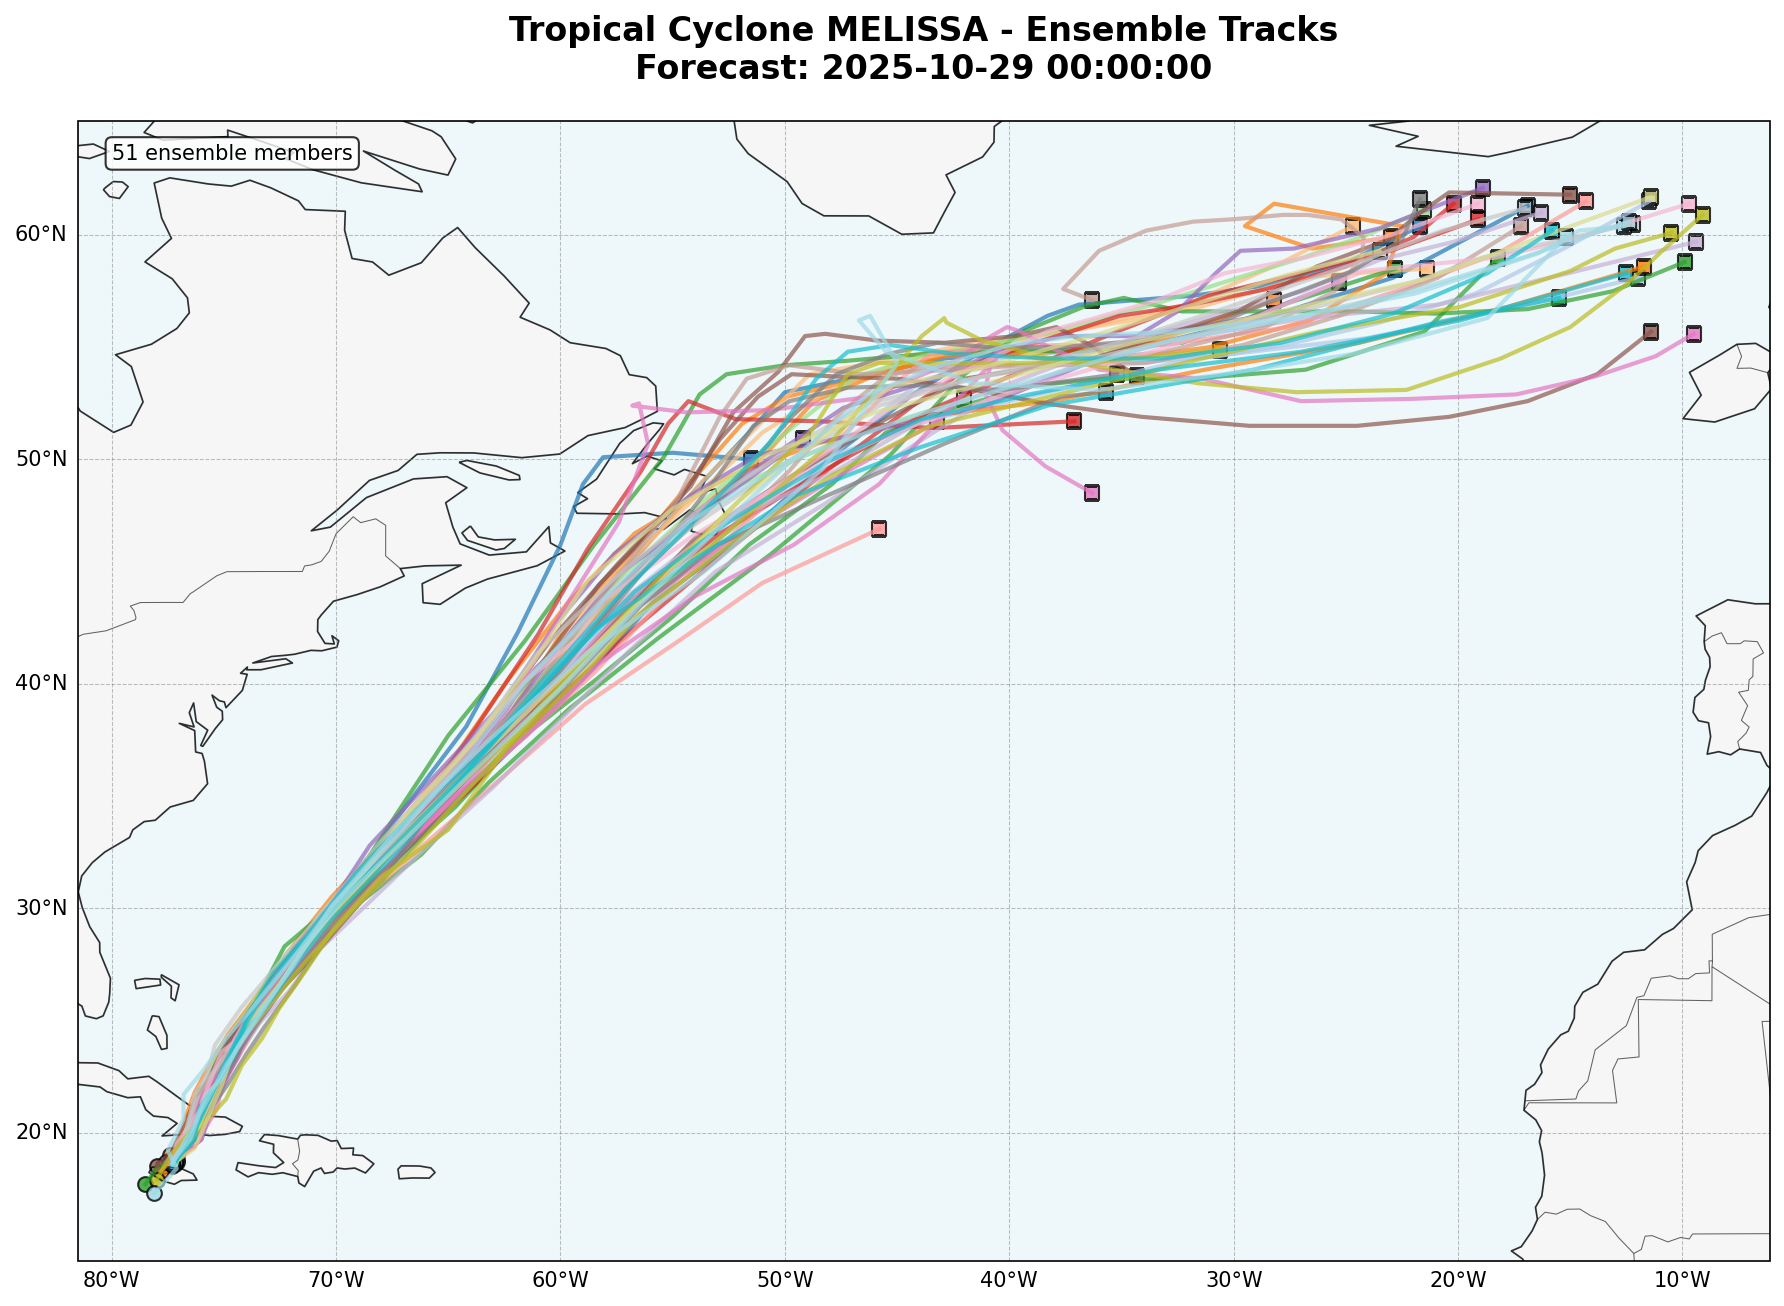

In [11]:
# Creating TC track visualization
show_tracks(str(transformed_files[0]))

TC TRACKS WITH WIND POLYGONS
Loaded 1172 track points from A_JSXX02ECEP290000_C_ECMP_20251029000000_tropical_cyclone_track_MELISSA_-77p9degW_17p9degN_bufr4_extracted_transformed.csv
Storm: MELISSA
Forecast: 2025-10-29 00:00:00
Showing 3 members
Wind polygon columns: ['wind_field_polygon_34kt', 'wind_field_polygon_50kt', 'wind_field_polygon_64kt']
Available wind thresholds: [34, 50, 64]


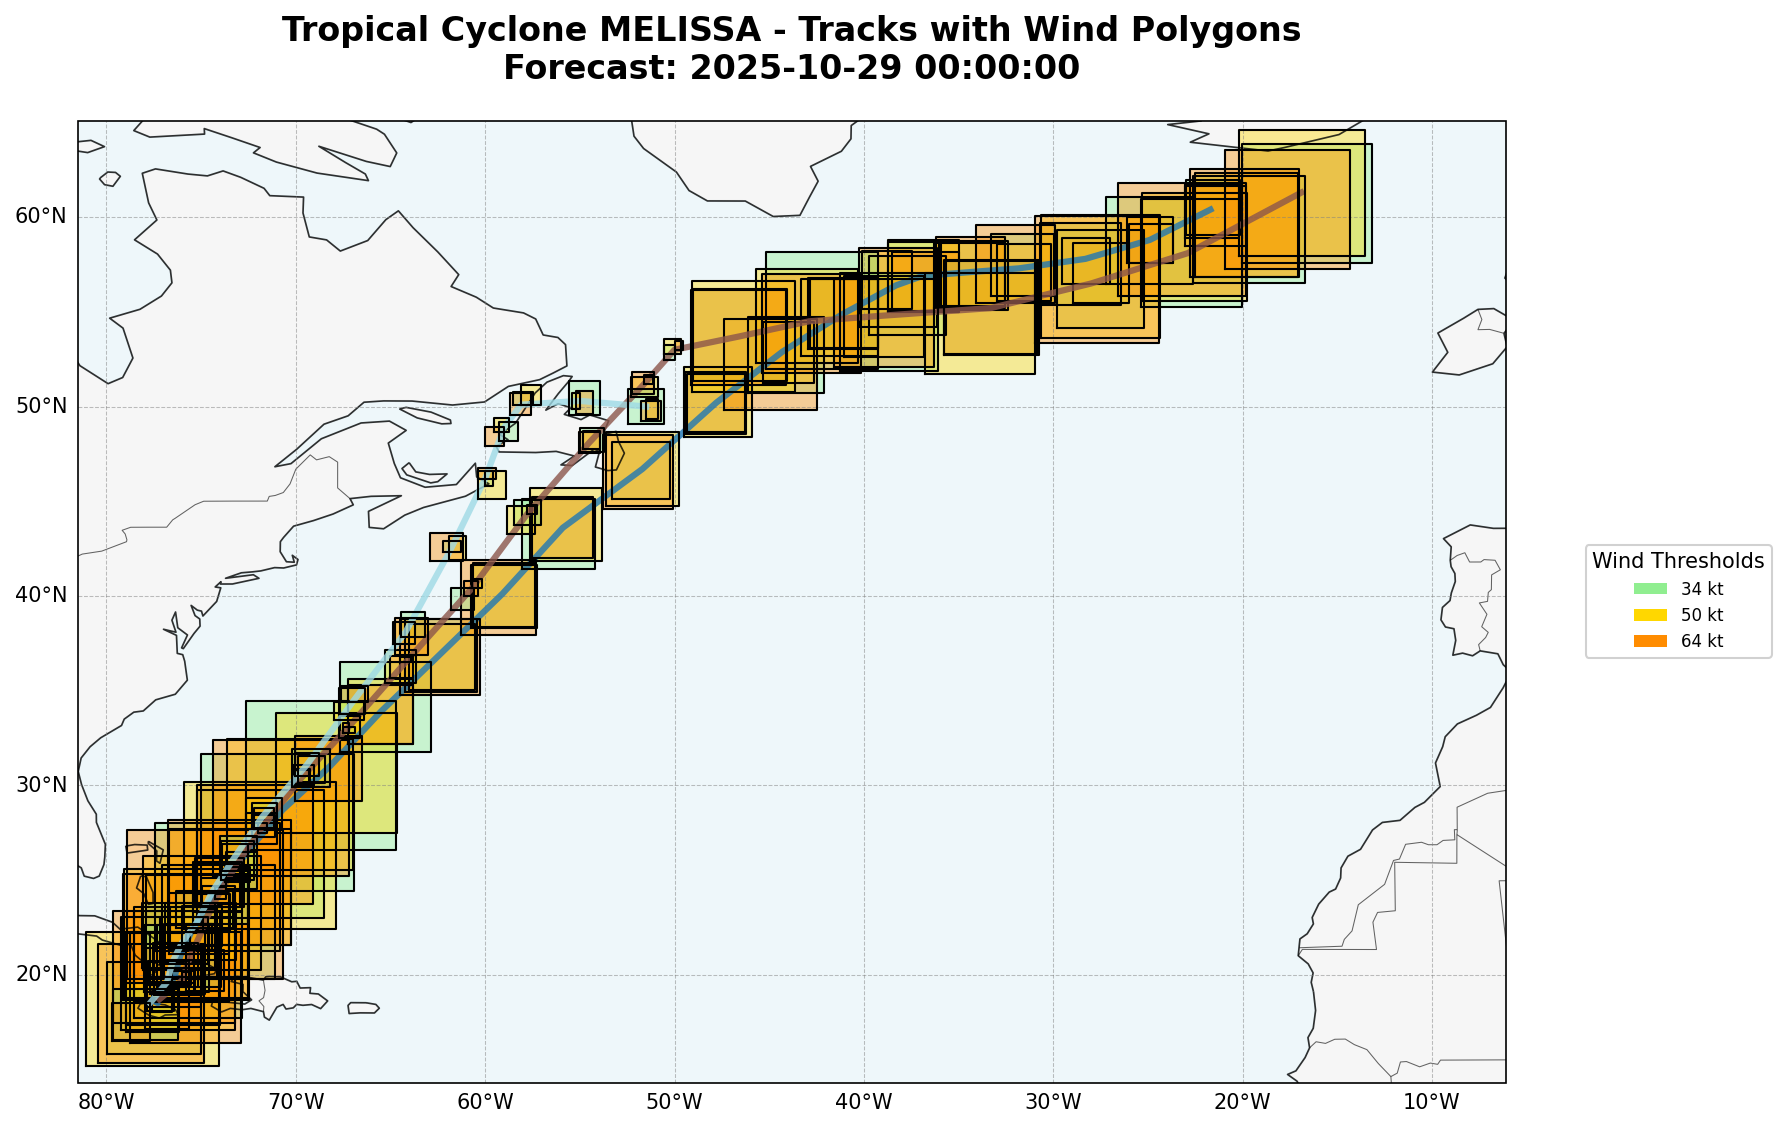

In [12]:
# Creating TC tracks with wind polygons visualization
show_tracks_with_polygons(str(transformed_files[0]))

INDIVIDUAL WIND ENVELOPES
Loaded 274 records from KALMAEGI_20251102T00Z_envelopes_individual.csv
Found 274 records with polygons
Storm: KALMAEGI
Forecast: 2025-11-02 00:00:00
Member: 1
Forecast steps: 22


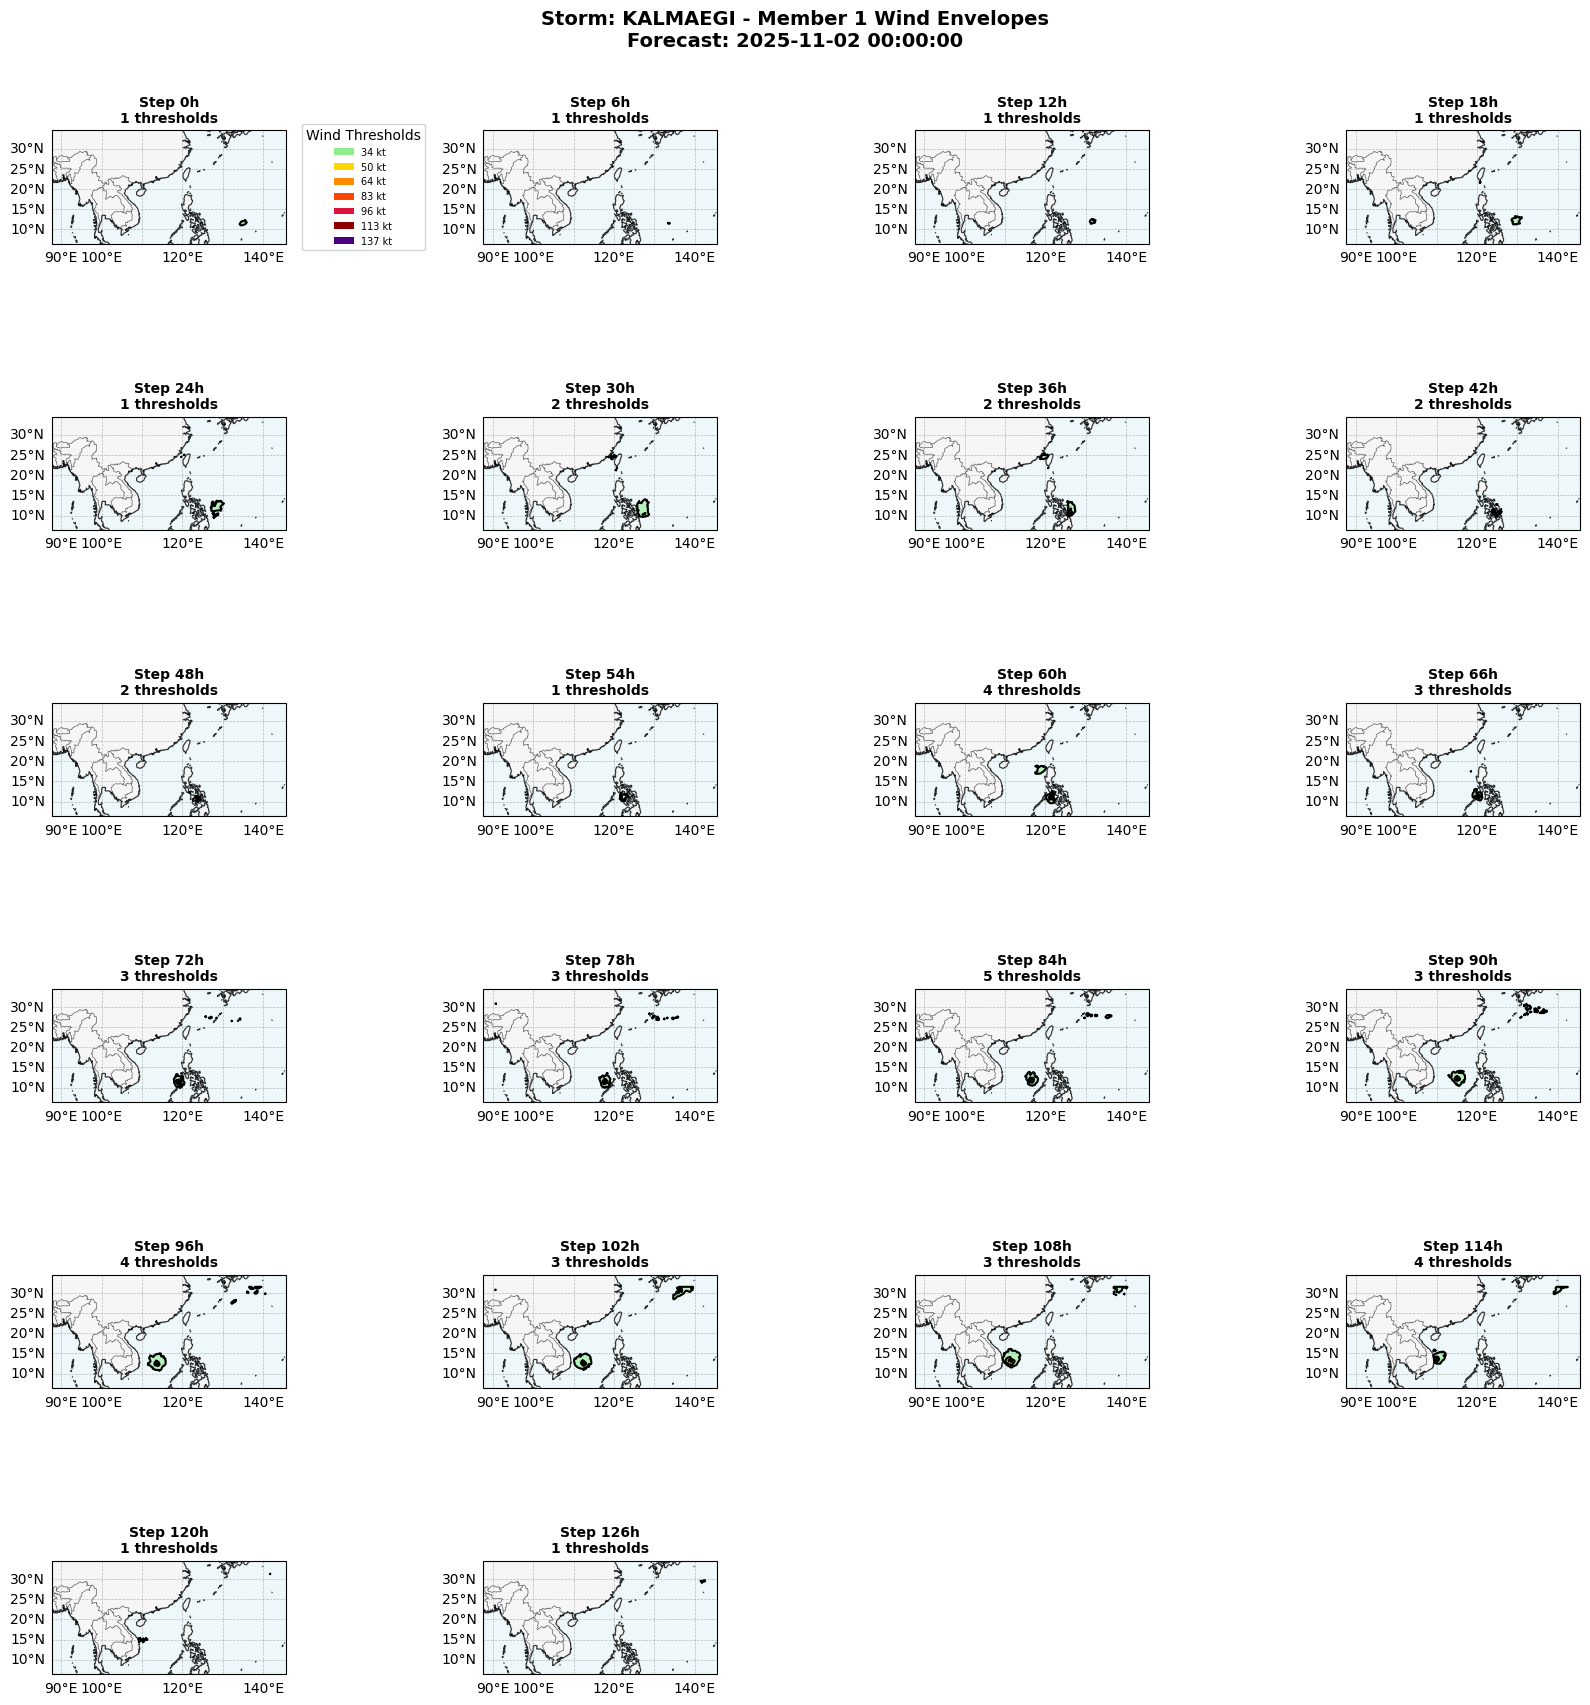

In [13]:
# Creating individual wind envelopes visualizatio
individual_files = [f for f in envelope_files if 'individual' in f.name]
show_individual_envelopes(str(individual_files[0]))

COMBINED WIND ENVELOPES
Loaded 17 records from KALMAEGI_20251102T00Z_envelopes_combined.csv
Found 17 records with polygons
Storm: KALMAEGI
Forecast: 2025-11-02 00:00:00
Showing 3 members


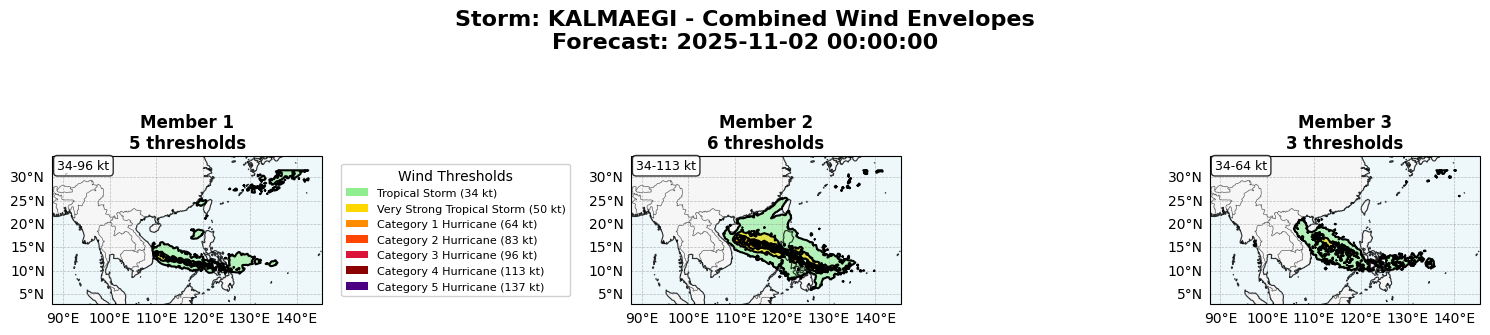

In [14]:
# Creating combined wind envelopes visualization
combined_files = [f for f in envelope_files if 'combined' in f.name]
show_combined_envelopes(str(combined_files[0]))